In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import math 

import sys 
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv


# Exploratory Data Analysis

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


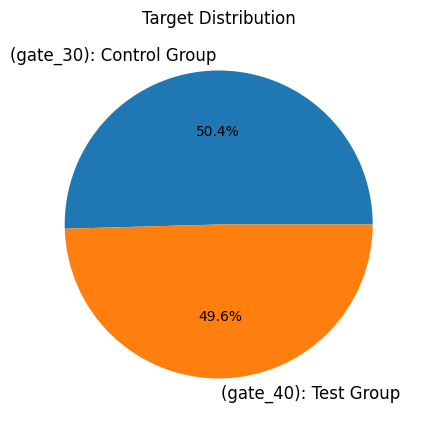

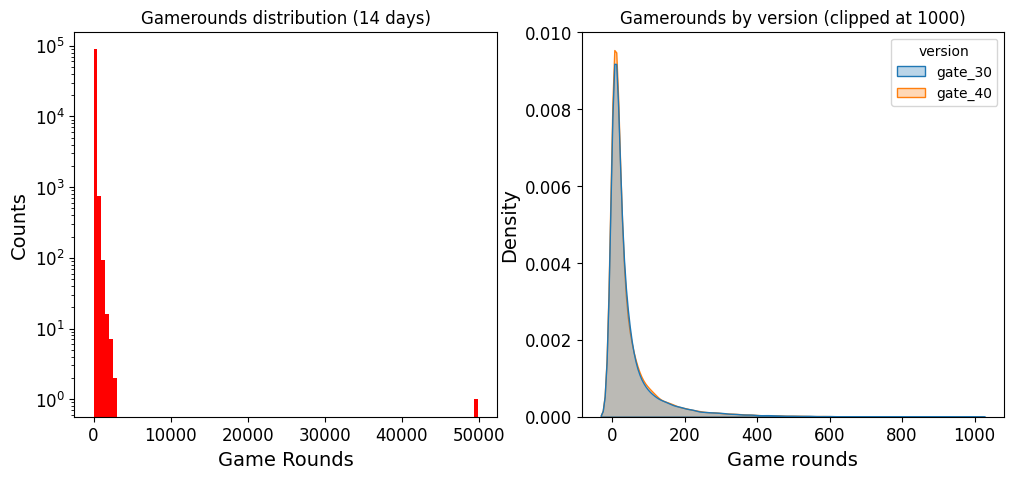

Outliers: 5704 players (6.32%)


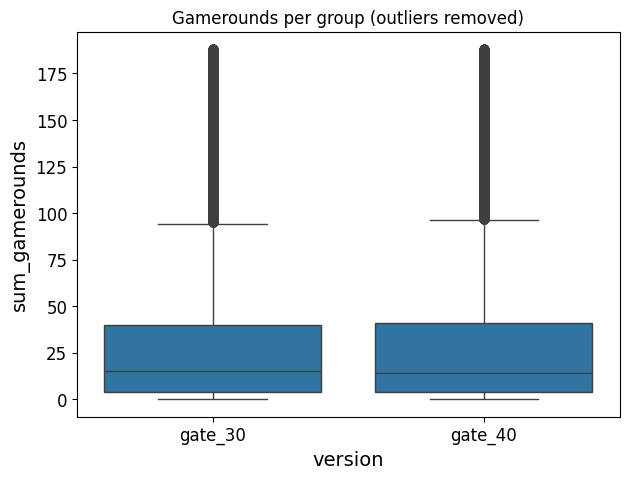

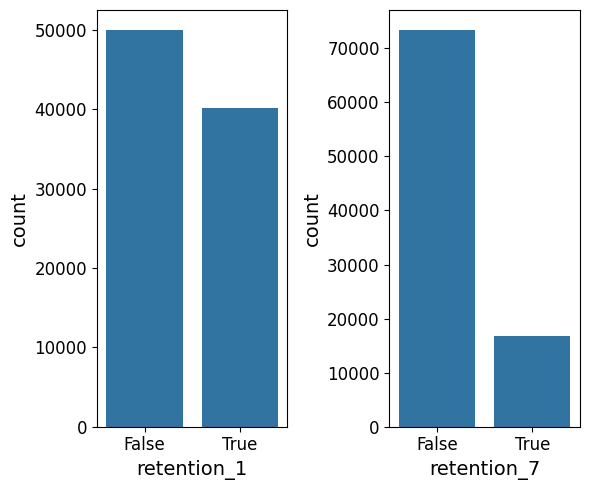

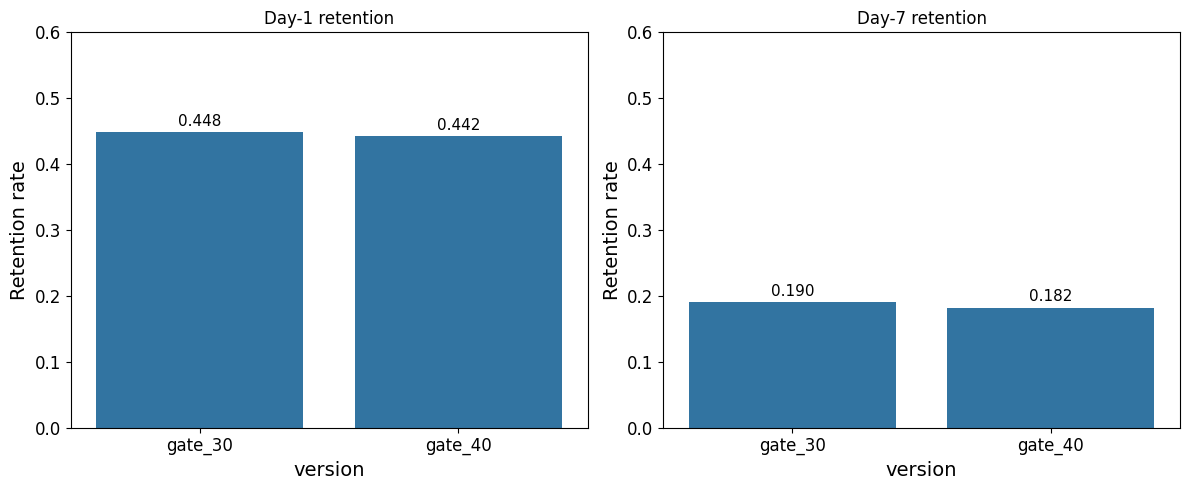

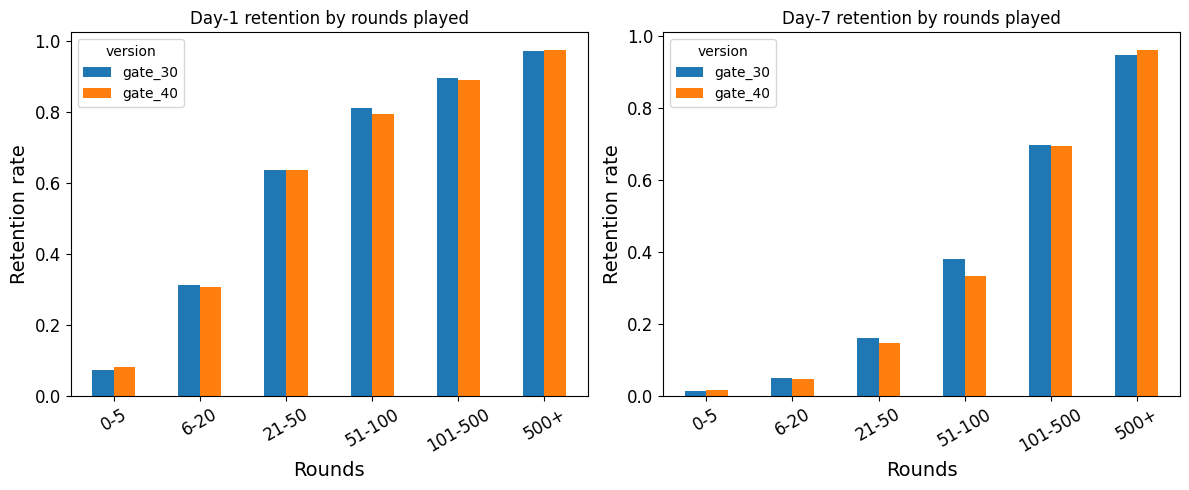

In [3]:
########### visualizations ###########################

# 1) Imbalance of control and test group

fig, ax = plt.subplots(figsize=(7,5))
ax.pie(df["version"].value_counts(), 
        labels = ["(gate_30): Control Group", "(gate_40): Test Group"],
       autopct = "%1.1f%%")
ax.set_title("Target Distribution")
plt.show()
plt.close()
    
# 2) Gamerounds distribution

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs = axs.flatten()
axs[0].hist(df["sum_gamerounds"], bins = 100, color = 'red')
axs[0].set_xlabel("Game Rounds")
axs[0].set_xscale('linear')
axs[0].set_ylabel("Counts")
axs[0].set_yscale('log')
axs[0].set_title("Gamerounds distribution (14 days)")

## Gamerounds distributions per group

sns.kdeplot(
    data = df[df["sum_gamerounds"] < 1000],
    x = "sum_gamerounds",
    hue = "version",
    ax = axs[1],
    fill = True,
    alpha = 0.3
)
axs[1].set_xlabel("Game rounds")
axs[1].set_title("Gamerounds by version (clipped at 1000)")

plt.show()
plt.close()

## outliers detection 
Q1 = df["sum_gamerounds"].quantile(0.25)
Q3 = df["sum_gamerounds"].quantile(0.75)
IQR = Q3 - Q1
### get the gamerounds in the outlier region
outliers = df[df["sum_gamerounds"] > Q3 + 3 * IQR]
print(f"Outliers: {len(outliers)} players ({len(outliers)/len(df)*100:.2f}%)")
### get the gamerounds pwe group without outliers
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df[df["sum_gamerounds"] < Q3 + 3*IQR],
            x="version", y="sum_gamerounds", ax=ax)
ax.set_title("Gamerounds per group (outliers removed)")
plt.show()
plt.close()


# 3) retention rates distributions

fig, axs = plt.subplots(1,2, figsize=(6,5))
axs = axs.flatten()

sns.countplot(
    data = df,
    x = "retention_1",
    ax = axs[0]
)

sns.countplot(
    data = df,
    x = "retention_7",
    ax = axs[1]
)
plt.tight_layout()
plt.show()
plt.close()

# retention rate per group

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axs,
                           ["retention_1", "retention_7"],
                           ["Day-1 retention", "Day-7 retention"]):
    rates = df.groupby("version")[col].mean().reset_index()
    sns.barplot(data=rates, x="version", y=col, ax=ax)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel("Retention rate")
    ax.set_title(title)
    for bar, val in zip(ax.patches, rates[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

# retention rate per group grouped into bins

df["grouped_gamerounds"] = pd.cut(df["sum_gamerounds"],
                              bins=[0, 5, 20, 50, 100, 500, 50000],
                              labels=["0-5","6-20","21-50","51-100","101-500","500+"])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axs, ["retention_1", "retention_7"],
                               ["Day-1 retention", "Day-7 retention"]):
    ct = df.groupby(["grouped_gamerounds", "version"], observed = True)[col].mean().unstack()
    ct.plot(kind="bar", ax=ax)
    ax.set_title(f"{title} by rounds played")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Retention rate")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## What do we observe from our DEA?

* The experiment is well-randomized: gate_30 (50.4%) and gate_40 (49.6%) are nearly equal in size, confirming no assignment bias.
*  The distribution of gamerounds is heavily right-skewed. The vast majority of player activity is concentrated below 200 rounds, with a long tail of high-engagement outliers. The median (not the mean) is the appropriate central tendency measure.
* Approximately 6% of players show extreme round counts beyond Q3 + 3×IQR. These were retained as legitimate user behavior and robust statistics were used to minimize their influence.
* Both groups show near-identical gamerounds distributions in shape, median, and spread, suggesting the gate position did not meaningfully affect overall engagement volume during the 14-day window.
* Day-7 retention (~ 18%) is significantly lower than Day-1 retention (~ 44%), indicating substantial churn between the first and seventh day — a normal pattern in mobile gaming.
* At face value, both groups show similar retention rates on Day-1 (~ 44%) and Day-7 (~ 18%). However, **gate_30 shows a marginally higher Day-7 retention, which warrants formal statistical testing to determine if the difference is significant.**
* Retention rate increases monotonically with engagement depth across both groups — **players who completed more rounds were substantially more likely to return on Day-1 and Day-7**

# Hypothesis framing

## Null and alternative hypothesis
* $H_{0}$ = P(retain_7 | gate_30) = P(retain_7 | gate_40) 

* $H_{1}$ = P(retain_7 | gate_40) different than P(retain_7 | gate_40)

Primary metric: retention rate on Day 7 

In [4]:
# Proportions per group
gate30 = df[df["version"] == "gate_30"]
gate40 = df[df["version"] == "gate_40"]

# Sample sizes for each retention metric
n30, n40 = len(gate30), len(gate40)

# number of success for each group
r7_30, r7_40 = gate30["retention_7"].sum(), gate40["retention_7"].sum()

# Observed proportions (effect size reference)

print(f"Day-7: gate_30={r7_30/n30:.4f}, gate_40={r7_40/n40:.4f}")

Day-7: gate_30=0.1902, gate_40=0.1820


# Statistical test selection

In [5]:
from statsmodels.stats.proportion import proportions_ztest

# two-tailed z-test 
z_stat, p_value = proportions_ztest(
    count = [r7_30, r7_40], # the number of successes in nobs trials.
    nobs = [n30, n40], # the number of trials or observations
    alternative = 'two-sided'
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

Z-statistic: 3.1644
P-value:     0.0016


In [6]:
from statsmodels.stats.proportion import proportion_confint

p30 = r7_30 / n30
p40 = r7_40 / n40
diff = p30 - p40

# 95% CI on the difference (via normal approximation)
se_diff = np.sqrt(p30*(1-p30)/n30 + p40*(1-p40)/n40)
ci_low  = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print(f"Observed difference: {diff:.4f} ({diff*100:.2f} pp)")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")


Observed difference: 0.0082 (0.82 pp)
95% CI: [0.0031, 0.0133]


## Observations
* There is statistically significant evidence that gate position affects Day-7 retention.
* for 10,000 players, gate_30 retains ~82 more users after 7 days.

# Segmentation Analysis

In [8]:
from statsmodels.stats.multitest import multipletests

segments = df["grouped_gamerounds"].cat.categories.tolist()
results = []

for seg in segments:
    mask = df["grouped_gamerounds"] == seg 
    g30 = df[mask & (df["version"] == "gate_30")]
    g40 = df[mask & (df["version"] == "gate_40")]
    n30, n40 = len(g30), len(g40)
    x30, x40 = g30["retention_7"].sum(), g40["retention_7"].sum()
    p30, p40 = x30/n30, x40/n40
    diff = p30 - p40
    z, p_raw   = proportions_ztest([x30, x40], [n30, n40], alternative="two-sided")
    results.append({
        "segment": seg,
        "n_gate30": n30, "n_gate40": n40,
        "p30": round(p30, 4), "p40": round(p40, 4),
        "diff_pp": round(diff * 100, 3),
        "z_stat": round(z, 3),
        "p_raw": round(p_raw, 4),
    })
results_df = pd.DataFrame(results)
    


In [9]:
results_df.head()

,segment,n_gate30,n_gate40,p30,p40,diff_pp,z_stat,p_raw
0,0-5,10119,10604,0.0129,0.0144,-0.148,-0.918,0.3588
1,6-20,12428,12657,0.0503,0.0475,0.281,1.031,0.3027
2,21-50,9080,8495,0.1607,0.1456,1.507,2.770,0.0056
3,51-100,5041,5386,0.3809,0.3331,4.779,5.093,0.0000
4,101-500,5668,5861,0.6962,0.6941,0.211,0.246,0.8057


In [10]:
# apply Bonferroni correction
reject, p_corrected, _, _ = multipletests(
    results_df["p_raw"], alpha=0.05, method="bonferroni"
)

results_df["p_corrected"] = p_corrected.round(4)
results_df["reject_H0"]   = reject

print(results_df[[
    "segment", "n_gate30", "n_gate40",
    "p30", "p40", "diff_pp",
    "p_raw", "p_corrected", "reject_H0"
]])

   segment  n_gate30  n_gate40     p30     p40  diff_pp   p_raw  p_corrected  \
0      0-5     10119     10604  0.0129  0.0144   -0.148  0.3588       1.0000   
1     6-20     12428     12657  0.0503  0.0475    0.281  0.3027       1.0000   
2    21-50      9080      8495  0.1607  0.1456    1.507  0.0056       0.0336   
3   51-100      5041      5386  0.3809  0.3331    4.779  0.0000       0.0000   
4  101-500      5668      5861  0.6962  0.6941    0.211  0.8057       1.0000   
5     500+       427       429  0.9485  0.9627   -1.423  0.3123       1.0000   

   reject_H0  
0      False  
1      False  
2       True  
3       True  
4      False  
5      False  


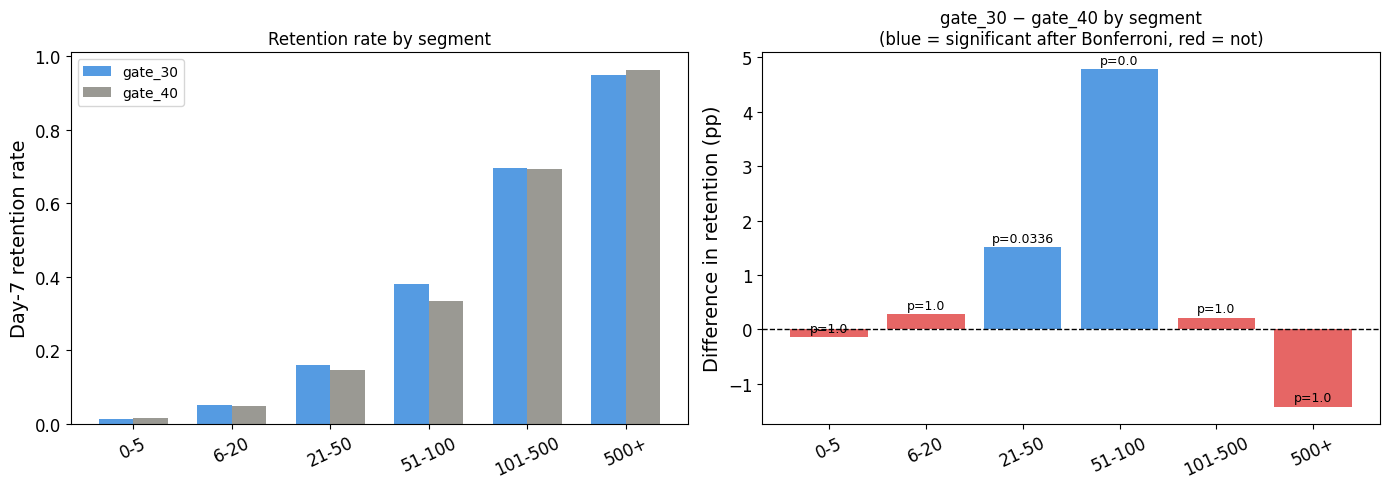

In [11]:
# visualize the effect

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#E24B4A" if not r else "#378ADD" for r in results_df["reject_H0"]]

# Left: retention rate per segment per group
x = np.arange(len(segments))
w = 0.35
axs[0].bar(x - w/2, results_df["p30"], w, label="gate_30", color="#378ADD", alpha=0.85)
axs[0].bar(x + w/2, results_df["p40"], w, label="gate_40", color="#888780", alpha=0.85)
axs[0].set_xticks(x)
axs[0].set_xticklabels(segments, rotation=25)
axs[0].set_ylabel("Day-7 retention rate")
axs[0].set_title("Retention rate by segment")
axs[0].legend()

# Right: difference (gate_30 - gate_40) per segment, colored by significance
bars = axs[1].bar(x, results_df["diff_pp"], color=colors, alpha=0.85)
axs[1].axhline(0, color="black", lw=1, linestyle="--")
axs[1].set_xticks(x)
axs[1].set_xticklabels(segments, rotation=25)
axs[1].set_ylabel("Difference in retention (pp)")
axs[1].set_title("gate_30 − gate_40 by segment\n(blue = significant after Bonferroni, red = not)")

for bar, row in zip(bars, results_df.itertuples()):
    axs[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f"p={row.p_corrected}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Observations

The global 0.82 pp advantage for gate_30 is not spread evenly — it's driven almost entirely by the 21-100 round segment, which represents players on the retention fence